# Crypto Multi-Canal - Visualisation des canaux ZigZag

## Objectif
Visualiser les canaux de prix (macro/meso) construits a partir du ZigZag pour valider
que les canaux generes sont coherents et "tradeables" avant d'optimiser l'algorithme.

## Approche
1. Charger les donnees BTC (et SPY pour comparaison)
2. Appliquer le ZigZag avec differents seuils (3%, 5%, 8%, 10%)
3. Construire les canaux support/resistance
4. Superposer les canaux aux prix sur des graphiques

> **[REFERENCE QC Cloud]**
> Ce notebook utilise QuantBook et necessite l'environnement QuantConnect Cloud.
> Pour executer : https://www.quantconnect.com/research


In [1]:
# Imports et setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timezone, datetime
import math

qb = QuantBook()

# Assets
btc = qb.add_crypto("BTCUSDT", Resolution.DAILY, Market.BINANCE).symbol
spy = qb.add_equity("SPY", Resolution.DAILY).symbol

print(f"BTC: {btc}, SPY: {spy}")

BTC: BTCUSDT, SPY: SPY


Les fonctions de calcul des canaux de tendance (support, résistance, ligne centrale) sont définies pour la stratégie Crypto-MultiCanal.

In [2]:
# === Channel helper functions (inline for research) ===

def get_line_params_time(p1_time_num, p1_price, p2_time_num, p2_price):
    time_diff = p2_time_num - p1_time_num
    if abs(time_diff) < 1e-9:
        return float('inf'), float(p1_time_num)
    m = (p2_price - p1_price) / time_diff
    c = p1_price - m * p1_time_num
    return m, c


def check_point_position(point_time_num, point_price, m, c, check_above, epsilon=1e-9):
    if m == float('inf'):
        return False
    line_y = m * point_time_num + c
    if check_above:
        return point_price >= line_y - epsilon
    else:
        return point_price <= line_y + epsilon


def calculate_weighted_sse(p1_time_num, p1_price, p2_time_num, p2_price,
                           pivots_np, time_min, time_max, weight_power=1.0):
    m, c = get_line_params_time(p1_time_num, p1_price, p2_time_num, p2_price)
    if m == float('inf'):
        return float('inf')
    if len(pivots_np) == 0:
        return 0.0
    total_wsse = 0.0
    total_weight = 0.0
    time_range = max(time_max - time_min, 1.0)
    for k in range(len(pivots_np)):
        pk_time, pk_price = pivots_np[k, 0], pivots_np[k, 1]
        if abs(pk_time - p1_time_num) < 1e-9 or abs(pk_time - p2_time_num) < 1e-9:
            continue
        normalized_time = max(0.0, (pk_time - time_min) / time_range)
        weight = normalized_time ** weight_power + 1e-9
        line_y = m * pk_time + c
        error = pk_price - line_y
        total_wsse += weight * (error ** 2)
        total_weight += weight
    return total_wsse / total_weight if total_weight > 1e-9 else 0.0


def find_best_channel_line(pivots_df, all_pivots_np, is_resistance,
                           weight_power=1.0, recent_pivot_fraction=1.0,
                           max_violation_pct=0.2):
    n_pivots = len(pivots_df)
    if n_pivots < 2 or len(all_pivots_np) < 1:
        return None, None
    check_df = pd.DataFrame(all_pivots_np, columns=['time_numeric', 'price'])
    check_df = check_df.sort_values('time_numeric', ascending=True)
    n_total = len(check_df)
    safe_rpf = max(0.0, min(1.0, recent_pivot_fraction))
    n_keep = max(1, math.ceil(n_total * safe_rpf))
    recent_df = check_df.tail(n_keep).copy()
    if recent_df.empty:
        return None, None
    max_violations = max(1, int(n_total * max_violation_pct))
    valid_lines = []
    for i in range(n_pivots):
        p1 = pivots_df.iloc[i]
        for j in range(i + 1, n_pivots):
            p2 = pivots_df.iloc[j]
            p1_t, p1_p = p1['time_numeric'], p1['price']
            p2_t, p2_p = p2['time_numeric'], p2['price']
            if p1_t >= p2_t:
                continue
            m, c = get_line_params_time(p1_t, p1_p, p2_t, p2_p)
            if m == float('inf'):
                continue
            violations = 0
            for k in range(n_total):
                pk_t, pk_p = all_pivots_np[k, 0], all_pivots_np[k, 1]
                if abs(pk_t - p1_t) < 1e-9 or abs(pk_t - p2_t) < 1e-9:
                    continue
                if not check_point_position(pk_t, pk_p, m, c, check_above=(not is_resistance)):
                    violations += 1
                    if violations > max_violations:
                        break
            if violations <= max_violations:
                wsse_df = recent_df[
                    (np.abs(recent_df['time_numeric'] - p1_t) > 1e-9) &
                    (np.abs(recent_df['time_numeric'] - p2_t) > 1e-9)
                ]
                wsse = 0.0
                if not wsse_df.empty:
                    wsse = calculate_weighted_sse(
                        p1_t, p1_p, p2_t, p2_p,
                        wsse_df[['time_numeric', 'price']].values,
                        wsse_df['time_numeric'].min(),
                        wsse_df['time_numeric'].max(),
                        weight_power
                    )
                if wsse != float('inf'):
                    valid_lines.append({"p1": p1, "p2": p2, "wsse": wsse,
                                       "violations": violations})
    if not valid_lines:
        return None, None
    valid_lines.sort(key=lambda x: (x['violations'], x['wsse']))
    best = valid_lines[0]
    return best['p1'], best['p2']


def classic_chart_zigzag(df, threshold_percent=0.05):
    if len(df) < 2:
        return []
    pivots = []
    first = df.iloc[0]
    last_price = float(first['close'])
    last_time = first['time']
    second = df.iloc[1]
    direction_up = float(second['close']) > last_price
    extreme_price = last_price
    extreme_time = last_time
    last_sign = 1 if direction_up else -1
    pivots.append({'time': last_time, 'price': last_price, 'type': last_sign})
    for i in range(1, len(df)):
        row = df.iloc[i]
        price = float(row['close'])
        time = row['time']
        if direction_up:
            if price > extreme_price:
                extreme_price = price
                extreme_time = time
            else:
                retrace = 1.0 - (price / extreme_price) if extreme_price != 0 else 0
                if retrace >= threshold_percent:
                    pivots.append({'time': extreme_time, 'price': extreme_price, 'type': -1})
                    direction_up = False
                    extreme_price = price
                    extreme_time = time
        else:
            if price < extreme_price:
                extreme_price = price
                extreme_time = time
            else:
                rally = (price / extreme_price) - 1.0 if extreme_price != 0 else float('inf')
                if rally >= threshold_percent:
                    pivots.append({'time': extreme_time, 'price': extreme_price, 'type': 1})
                    direction_up = True
                    extreme_price = price
                    extreme_time = time
    if len(pivots) > 1 and pivots[-1]['type'] == pivots[-2]['type']:
        if pivots[-1]['type'] == 1:
            if pivots[-1]['price'] < pivots[-2]['price']:
                pivots.pop(-2)
            else:
                pivots.pop(-1)
        else:
            if pivots[-1]['price'] > pivots[-2]['price']:
                pivots.pop(-2)
            else:
                pivots.pop(-1)
    if pivots and pivots[-1]['type'] != (-1 if direction_up else 1):
        pivots.append({'time': extreme_time, 'price': extreme_price,
                       'type': (-1 if direction_up else 1)})
    return pivots


print("Helper functions loaded.")

Helper functions loaded.


Extraction de la série de clôture BTCUSD et vérification de la plage temporelle disponible.

In [3]:
# === Load BTC data ===
btc_history = qb.history(btc, 750, Resolution.DAILY)
if isinstance(btc_history.index, pd.MultiIndex):
    btc_history = btc_history.loc[btc]

if len(btc_history) == 0:
    btc_df = None
    print("WARNING: No BTCUSDT data returned from QC Cloud.")
    print("Crypto daily data may not be available in this environment.")
    print("All BTC-dependent analysis cells will be skipped.")
else:
    btc_df = btc_history.reset_index()

    # Find the time column
    time_col = None
    for col in btc_df.columns:
        if 'time' in col.lower() or 'date' in col.lower() or col == 'index':
            time_col = col
            break
    if time_col and time_col != 'time':
        btc_df = btc_df.rename(columns={time_col: 'time'})

    btc_df['time'] = pd.to_datetime(btc_df['time'])
    if btc_df['time'].dt.tz is None:
        btc_df['time'] = btc_df['time'].dt.tz_localize('UTC')

    print(f"BTC data: {len(btc_df)} bars, from {btc_df['time'].iloc[0]} to {btc_df['time'].iloc[-1]}")
    print(f"Price range: ${btc_df['close'].min():.0f} - ${btc_df['close'].max():.0f}")

BTC data: 750 bars, from 2024-05-13 00:00:00+00:00 to 2026-06-01 00:00:00+00:00
Price range: $53963 - $124659


Construction des pivots ZigZag pour les seuils 0.03, 0.05, 0.08 et détection des canaux de prix sur BTC.

In [4]:
if btc_df is None:
    print("BTC data not available — skipping ZigZag pivot detection.")
    df_zz = None
    zigzag_results = {}
else:
    # === Compute ZigZag pivots at different thresholds ===
    thresholds = [0.03, 0.05, 0.08, 0.10, 0.15]
    zigzag_results = {}

    df_zz = btc_df[['time', 'close']].copy()

    for thresh in thresholds:
        pivots = classic_chart_zigzag(df_zz, thresh)
        zigzag_results[thresh] = pivots
        n_high = sum(1 for p in pivots if p['type'] == -1)
        n_low = sum(1 for p in pivots if p['type'] == 1)
        print(f"ZigZag {thresh*100:.0f}%: {len(pivots)} pivots ({n_high} highs, {n_low} lows)")

ZigZag 3%: 97 pivots (48 highs, 49 lows)
ZigZag 5%: 53 pivots (26 highs, 27 lows)


ZigZag 8%: 33 pivots (16 highs, 17 lows)
ZigZag 10%: 22 pivots (11 highs, 11 lows)


ZigZag 15%: 11 pivots (5 highs, 6 lows)


Construction des pivots ZigZag pour les seuils 0.6, 0.8, 1.2 et détection des canaux de prix sur BTC.

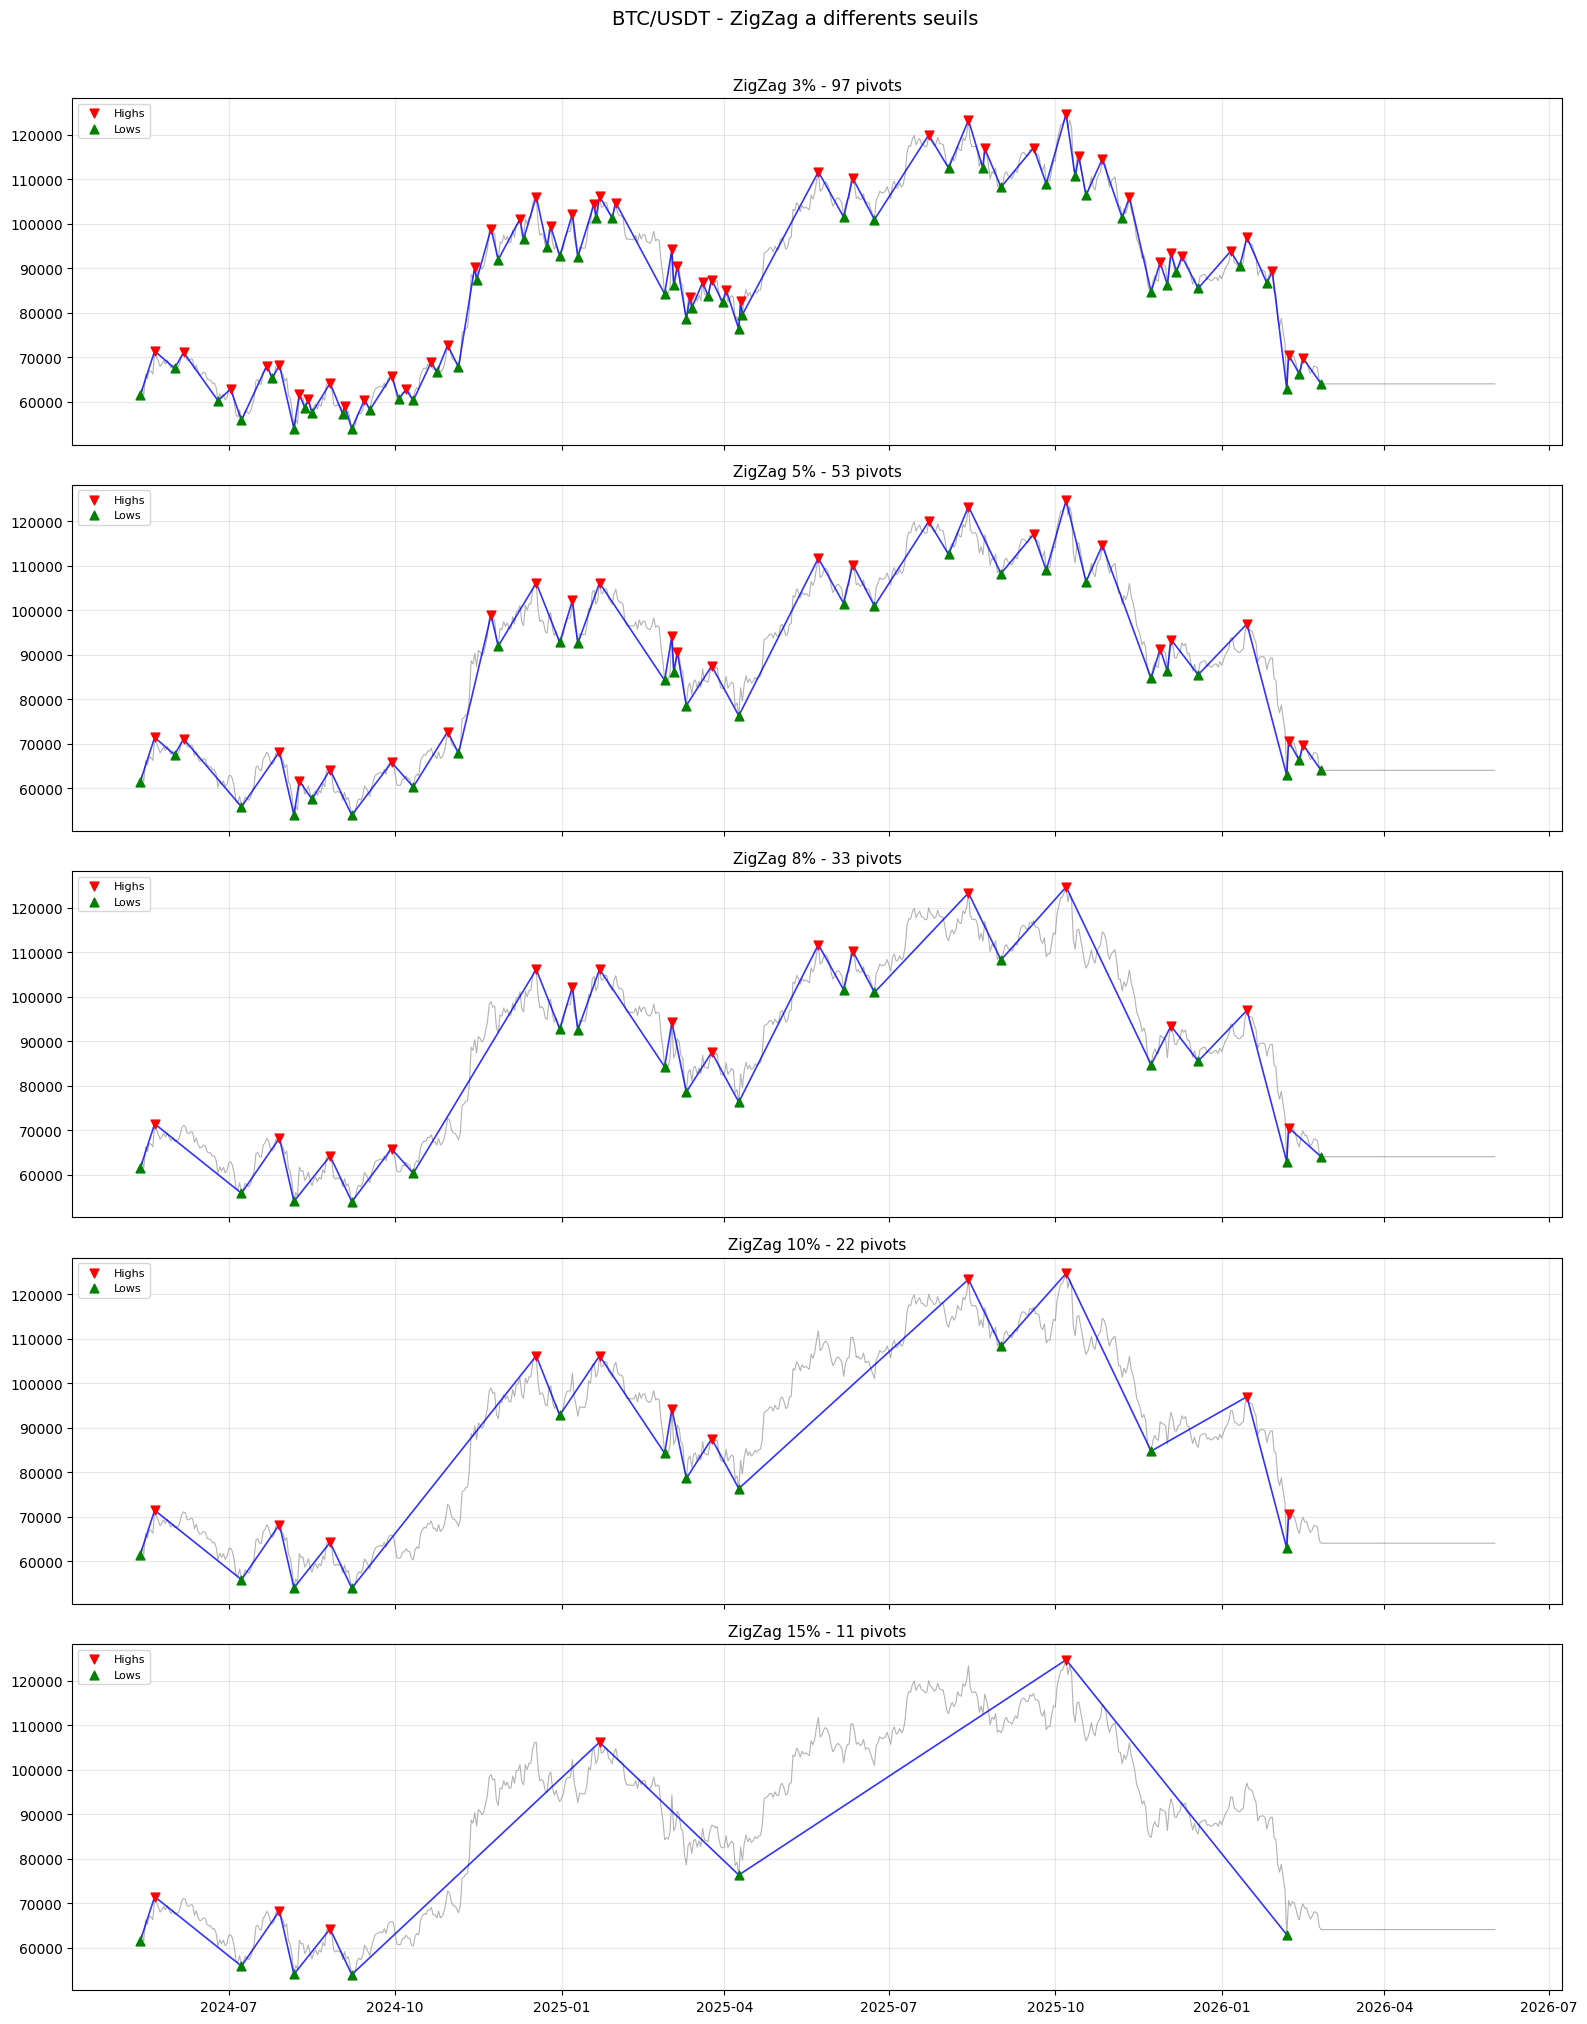

Graphique sauvegarde: zigzag_thresholds.png


In [5]:
if btc_df is None or df_zz is None:
    print("BTC data not available — skipping ZigZag visualization.")
else:
    # === Visualize ZigZag at different thresholds ===
    fig, axes = plt.subplots(len(thresholds), 1, figsize=(16, 4 * len(thresholds)), sharex=True)

    for idx, thresh in enumerate(thresholds):
        ax = axes[idx]
        ax.plot(btc_df['time'], btc_df['close'], color='gray', alpha=0.6, linewidth=0.8)

        pivots = zigzag_results[thresh]
        if pivots:
            pivot_times = [p['time'] for p in pivots]
            pivot_prices = [p['price'] for p in pivots]
            pivot_types = [p['type'] for p in pivots]

            # Draw ZigZag line
            ax.plot(pivot_times, pivot_prices, color='blue', linewidth=1.2, alpha=0.8)

            # Mark highs (red) and lows (green)
            highs = [(t, p) for t, p, tp in zip(pivot_times, pivot_prices, pivot_types) if tp == -1]
            lows = [(t, p) for t, p, tp in zip(pivot_times, pivot_prices, pivot_types) if tp == 1]
            if highs:
                ax.scatter([h[0] for h in highs], [h[1] for h in highs],
                          color='red', marker='v', s=40, zorder=5, label='Highs')
            if lows:
                ax.scatter([l[0] for l in lows], [l[1] for l in lows],
                          color='green', marker='^', s=40, zorder=5, label='Lows')

        ax.set_title(f'ZigZag {thresh*100:.0f}% - {len(pivots)} pivots', fontsize=11)
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('BTC/USDT - ZigZag a differents seuils', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('zigzag_thresholds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegarde: zigzag_thresholds.png")

Construction des pivots ZigZag pour les seuils 0.3, 2.0, 1.0 et détection des canaux de prix sur BTC.

In [6]:
# === Build and visualize channels for a given threshold ===

def build_channels(df_zz, zigzag_threshold, max_violation_pct=0.3):
    """Build macro and meso channels from ZigZag pivots."""
    pivot_list = classic_chart_zigzag(df_zz, zigzag_threshold)
    if not pivot_list or len(pivot_list) < 4:
        return None, None, None
    
    pivots_df = pd.DataFrame(pivot_list)
    pivots_df['time'] = pd.to_datetime(pivots_df['time'])
    if pivots_df['time'].dt.tz is None:
        pivots_df['time_numeric'] = pivots_df['time'].apply(
            lambda x: x.replace(tzinfo=timezone.utc).timestamp()
        )
    else:
        pivots_df['time_numeric'] = pivots_df['time'].apply(lambda x: x.timestamp())
    
    high_df = pivots_df[pivots_df['type'] == -1].copy()
    low_df = pivots_df[pivots_df['type'] == 1].copy()
    
    if len(high_df) < 2 or len(low_df) < 2:
        return pivots_df, None, None
    
    channels = {}
    
    # MACRO: all pivots
    high_np = high_df[['time_numeric', 'price']].values
    low_np = low_df[['time_numeric', 'price']].values
    
    r1, r2 = find_best_channel_line(high_df, high_np, True, 2.0, 1.0, max_violation_pct)
    s1, s2 = find_best_channel_line(low_df, low_np, False, 2.0, 1.0, max_violation_pct)
    channels['macro'] = {
        'resistance': (r1, r2) if r1 is not None else (None, None),
        'support': (s1, s2) if s1 is not None else (None, None)
    }
    
    # MESO: recent 1/3 of pivots
    n_total = len(pivots_df)
    meso_count = max(6, n_total // 3)
    recent_pivots = pivots_df.tail(meso_count)
    meso_high = recent_pivots[recent_pivots['type'] == -1].copy()
    meso_low = recent_pivots[recent_pivots['type'] == 1].copy()
    
    if len(meso_high) >= 2 and len(meso_low) >= 2:
        mh_np = meso_high[['time_numeric', 'price']].values
        ml_np = meso_low[['time_numeric', 'price']].values
        mr1, mr2 = find_best_channel_line(meso_high, mh_np, True, 2.0, 1.0, max_violation_pct)
        ms1, ms2 = find_best_channel_line(meso_low, ml_np, False, 2.0, 1.0, max_violation_pct)
        channels['meso'] = {
            'resistance': (mr1, mr2) if mr1 is not None else (None, None),
            'support': (ms1, ms2) if ms1 is not None else (None, None)
        }
    else:
        channels['meso'] = {'resistance': (None, None), 'support': (None, None)}
    
    return pivots_df, channels, (high_df, low_df)


def plot_channel_line(ax, p1, p2, time_range, color, linestyle, label):
    """Plot a channel line (support or resistance) across a time range."""
    if p1 is None or p2 is None:
        return
    t1 = p1['time_numeric']
    t2 = p2['time_numeric']
    m, c = get_line_params_time(t1, p1['price'], t2, p2['price'])
    if m == float('inf'):
        return
    
    # Extend line across the full time range
    t_start = time_range[0].replace(tzinfo=timezone.utc).timestamp() if time_range[0].tzinfo is None else time_range[0].timestamp()
    t_end = time_range[-1].replace(tzinfo=timezone.utc).timestamp() if time_range[-1].tzinfo is None else time_range[-1].timestamp()
    
    # Only plot from the first pivot point onward
    t_plot_start = max(t_start, min(t1, t2))
    t_plot_end = t_end
    
    times_num = np.linspace(t_plot_start, t_plot_end, 200)
    values = m * times_num + c
    times_dt = pd.to_datetime(times_num, unit='s', utc=True)
    
    ax.plot(times_dt, values, color=color, linestyle=linestyle, linewidth=1.5, 
            alpha=0.8, label=label)
    # Mark the anchor points
    for p in [p1, p2]:
        pt = pd.to_datetime(p['time_numeric'], unit='s', utc=True)
        ax.plot(pt, p['price'], 'o', color=color, markersize=6)


print("Channel builder and plotter ready.")

Channel builder and plotter ready.


Construction des pivots ZigZag pour les seuils 0.05, 0.3 et détection des canaux de prix sur BTC.

In [7]:
if btc_df is None or df_zz is None:
    print("BTC data not available — skipping channel building.")
    pivots_df = None
    channels = None
    high_df = None
    low_df = None
else:
    # === Main visualization: BTC channels at 5% ZigZag threshold ===
    THRESHOLD = 0.05
    VIOLATION_PCT = 0.3

    pivots_df, channels, (high_df, low_df) = build_channels(
        df_zz, THRESHOLD, VIOLATION_PCT
    )

    print(f"\nZigZag {THRESHOLD*100:.0f}% : {len(pivots_df)} pivots")
    for scale in ['macro', 'meso']:
        ch = channels[scale]
        res_ok = ch['resistance'][0] is not None
        sup_ok = ch['support'][0] is not None
        print(f"  {scale}: resistance={'OK' if res_ok else 'None'}, support={'OK' if sup_ok else 'None'}")
        if res_ok:
            r1, r2 = ch['resistance']
            m, _ = get_line_params_time(r1['time_numeric'], r1['price'], r2['time_numeric'], r2['price'])
            print(f"    Res slope: {m*86400:.1f} $/day")
        if sup_ok:
            s1, s2 = ch['support']
            m, _ = get_line_params_time(s1['time_numeric'], s1['price'], s2['time_numeric'], s2['price'])
            print(f"    Sup slope: {m*86400:.1f} $/day")


ZigZag 5% : 53 pivots
  macro: resistance=OK, support=OK
    Res slope: 25.0 $/day
    Sup slope: 17.3 $/day
  meso: resistance=OK, support=OK
    Res slope: -277.1 $/day
    Sup slope: -286.9 $/day


Construction des pivots ZigZag pour les seuils 0.8, 0.7, 0.5 et détection des canaux de prix sur BTC.

KeyError: -1

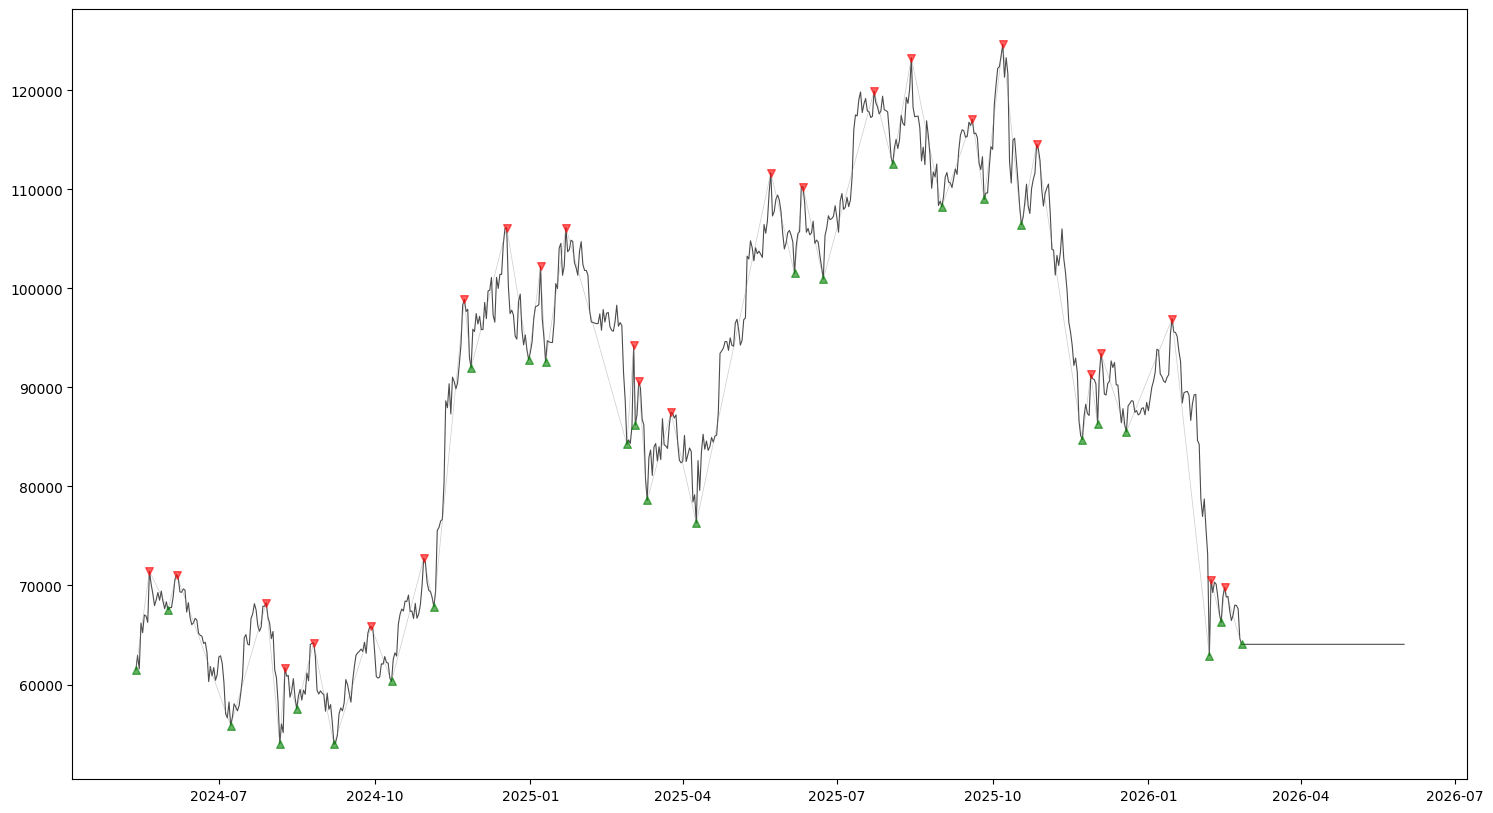

In [8]:
if btc_df is None or pivots_df is None or channels is None:
    print("BTC data or channels not available — skipping macro+meso channel plot.")
else:
    # === Plot: BTC price with macro + meso channels ===
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))

    # Price
    ax.plot(btc_df['time'], btc_df['close'], color='black', linewidth=0.8, alpha=0.7, label='BTC Close')

    # ZigZag pivots
    pivot_times = pivots_df['time'].values
    pivot_prices = pivots_df['price'].values
    ax.plot(pivot_times, pivot_prices, color='gray', linewidth=0.5, alpha=0.4)

    # Highs and lows markers
    ax.scatter(high_df['time'].values, high_df['price'].values,
              color='red', marker='v', s=30, zorder=5, alpha=0.6, label='ZZ Highs')
    ax.scatter(low_df['time'].values, low_df['price'].values,
              color='green', marker='^', s=30, zorder=5, alpha=0.6, label='ZZ Lows')

    # Macro channels (thick, dashed)
    ch = channels['macro']
    if ch['resistance'][0] is not None:
        plot_channel_line(ax, ch['resistance'][0], ch['resistance'][1],
                         btc_df['time'], 'red', '--', 'Macro Resistance')
    if ch['support'][0] is not None:
        plot_channel_line(ax, ch['support'][0], ch['support'][1],
                         btc_df['time'], 'green', '--', 'Macro Support')

    # Meso channels (solid, thinner)
    ch = channels['meso']
    if ch['resistance'][0] is not None:
        plot_channel_line(ax, ch['resistance'][0], ch['resistance'][1],
                         btc_df['time'], 'darkred', '-', 'Meso Resistance')
    if ch['support'][0] is not None:
        plot_channel_line(ax, ch['support'][0], ch['support'][1],
                         btc_df['time'], 'darkgreen', '-', 'Meso Support')

    ax.set_title(f'BTC/USDT - Canaux ZigZag {THRESHOLD*100:.0f}% (Macro + Meso)', fontsize=14)
    ax.set_ylabel('Price (USDT)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('btc_channels_5pct.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegarde: btc_channels_5pct.png")

Construction des pivots ZigZag pour les seuils 0.05, 0.08, 0.10 et détection des canaux de prix sur BTC.

KeyError: -1

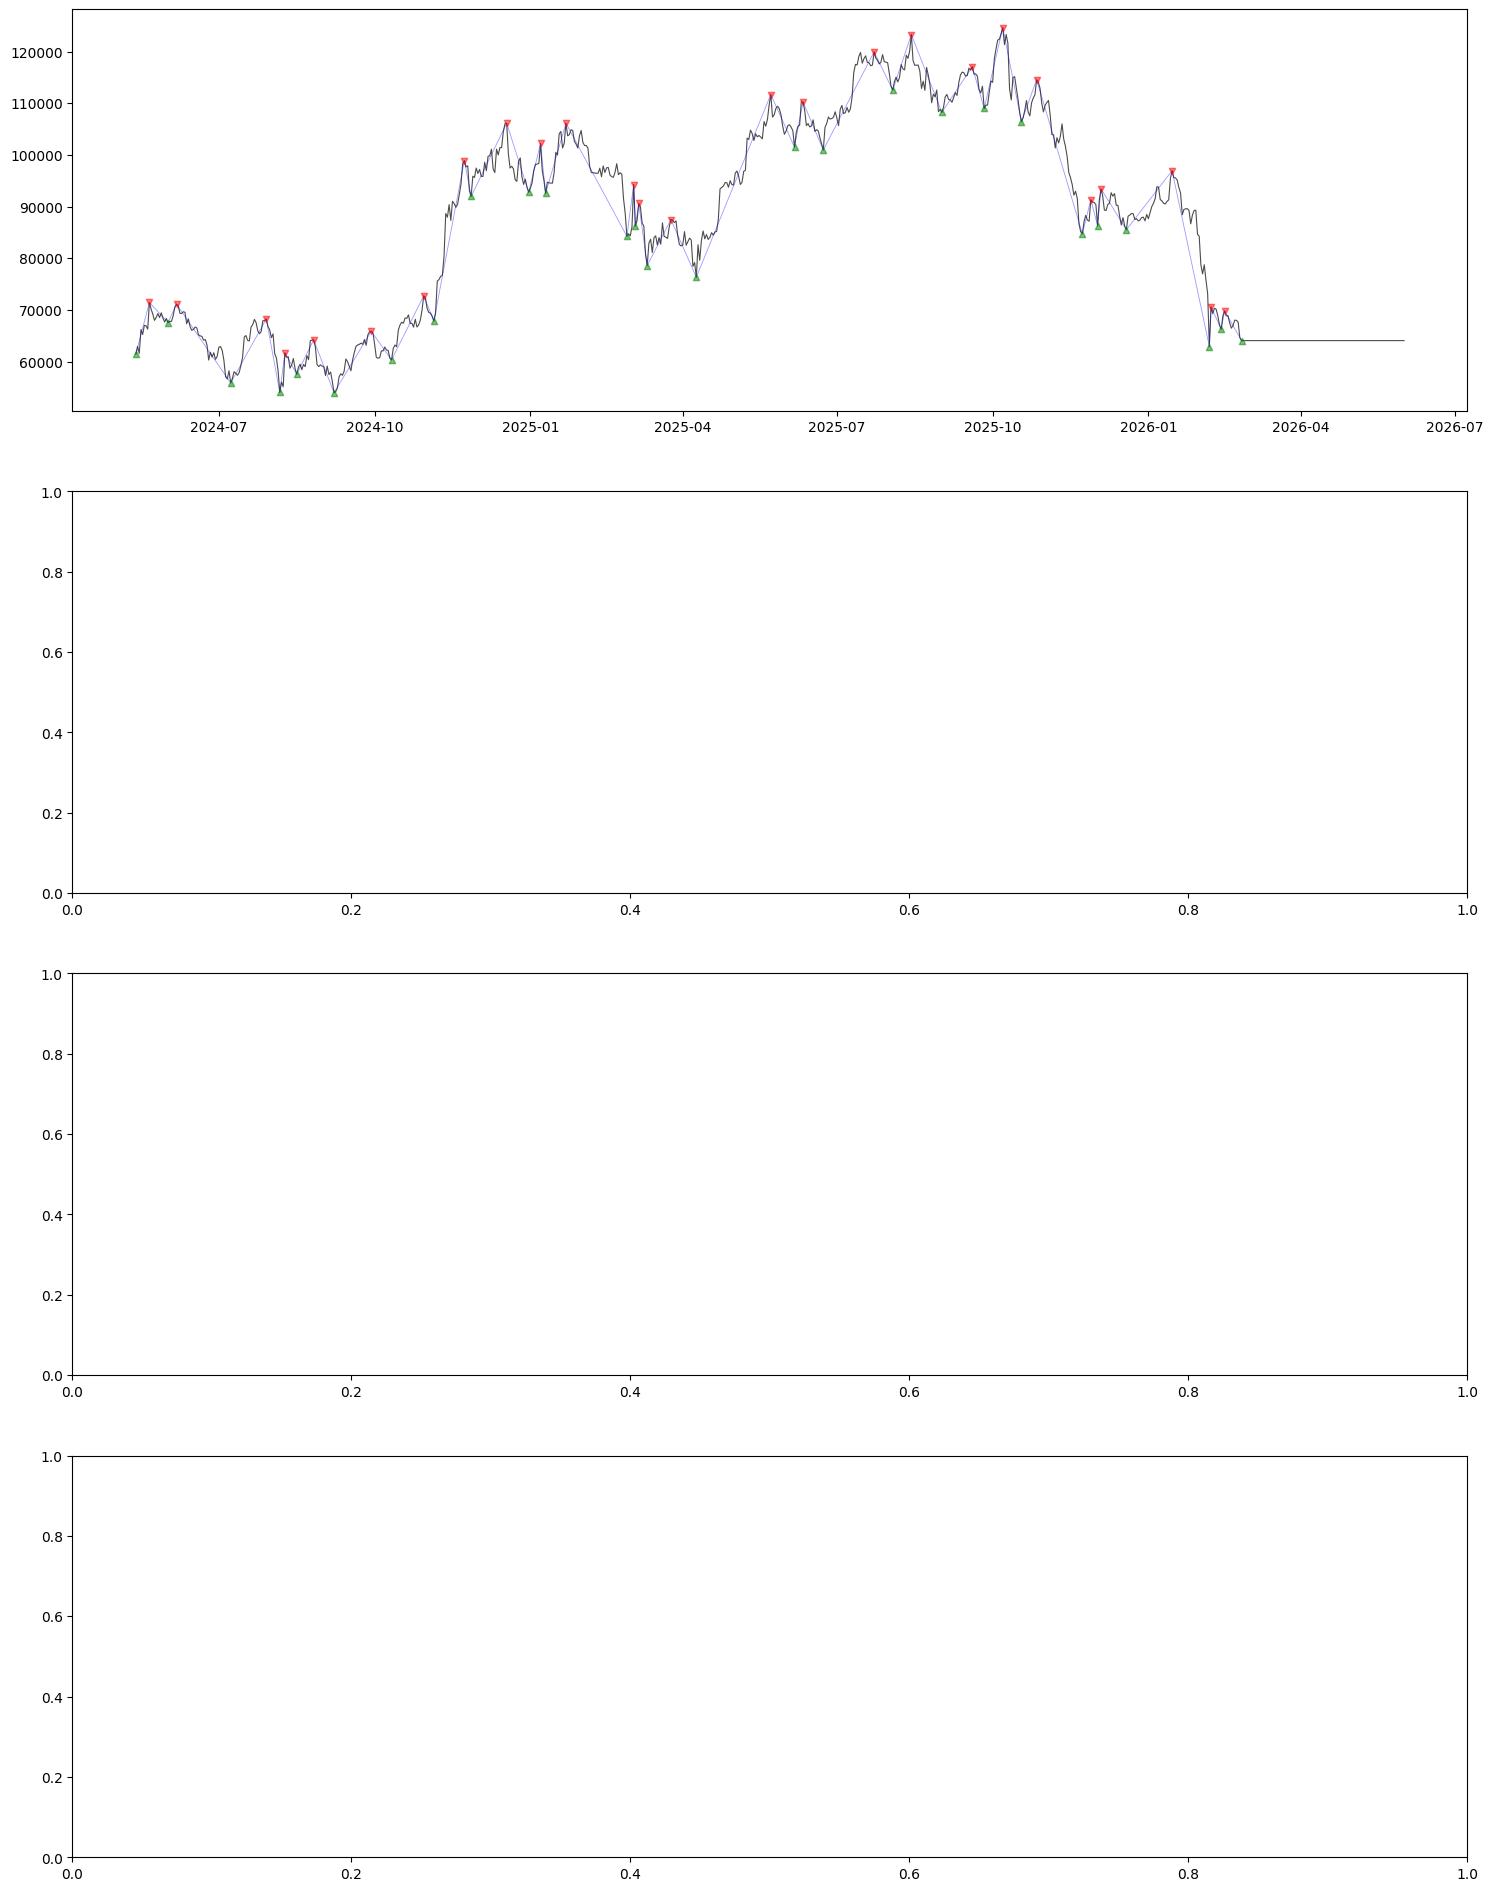

In [9]:
if btc_df is None or df_zz is None:
    print("BTC data not available — skipping multi-threshold channel comparison.")
else:
    # === Compare multiple thresholds side by side ===
    test_thresholds = [0.05, 0.08, 0.10, 0.15]

    fig, axes = plt.subplots(len(test_thresholds), 1, figsize=(18, 6 * len(test_thresholds)))

    for idx, thresh in enumerate(test_thresholds):
        ax = axes[idx]

        # Price
        ax.plot(btc_df['time'], btc_df['close'], color='black', linewidth=0.8, alpha=0.7)

        # Build channels
        result = build_channels(df_zz, thresh, VIOLATION_PCT)
        if result[1] is None:
            ax.set_title(f'ZigZag {thresh*100:.0f}% - Pas assez de pivots', fontsize=11)
            continue

        piv_df, chs, (h_df, l_df) = result

        # ZigZag
        ax.plot(piv_df['time'].values, piv_df['price'].values, color='blue', linewidth=0.6, alpha=0.4)
        ax.scatter(h_df['time'].values, h_df['price'].values,
                  color='red', marker='v', s=20, zorder=5, alpha=0.5)
        ax.scatter(l_df['time'].values, l_df['price'].values,
                  color='green', marker='^', s=20, zorder=5, alpha=0.5)

        # Macro channels
        ch = chs['macro']
        if ch['resistance'][0] is not None:
            plot_channel_line(ax, ch['resistance'][0], ch['resistance'][1],
                             btc_df['time'], 'red', '--', 'Macro Res')
        if ch['support'][0] is not None:
            plot_channel_line(ax, ch['support'][0], ch['support'][1],
                             btc_df['time'], 'green', '--', 'Macro Sup')

        # Meso channels
        ch = chs['meso']
        if ch['resistance'][0] is not None:
            plot_channel_line(ax, ch['resistance'][0], ch['resistance'][1],
                             btc_df['time'], 'darkred', '-', 'Meso Res')
        if ch['support'][0] is not None:
            plot_channel_line(ax, ch['support'][0], ch['support'][1],
                             btc_df['time'], 'darkgreen', '-', 'Meso Sup')

        n_piv = len(piv_df)
        ax.set_title(f'ZigZag {thresh*100:.0f}% - {n_piv} pivots', fontsize=11)
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('BTC/USDT - Canaux a differents seuils ZigZag', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('btc_channels_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegarde: btc_channels_comparison.png")

Construction des pivots ZigZag pour les seuils 0.05, 0.10, 1.0 et détection des canaux de prix sur BTC.

KeyError: -1

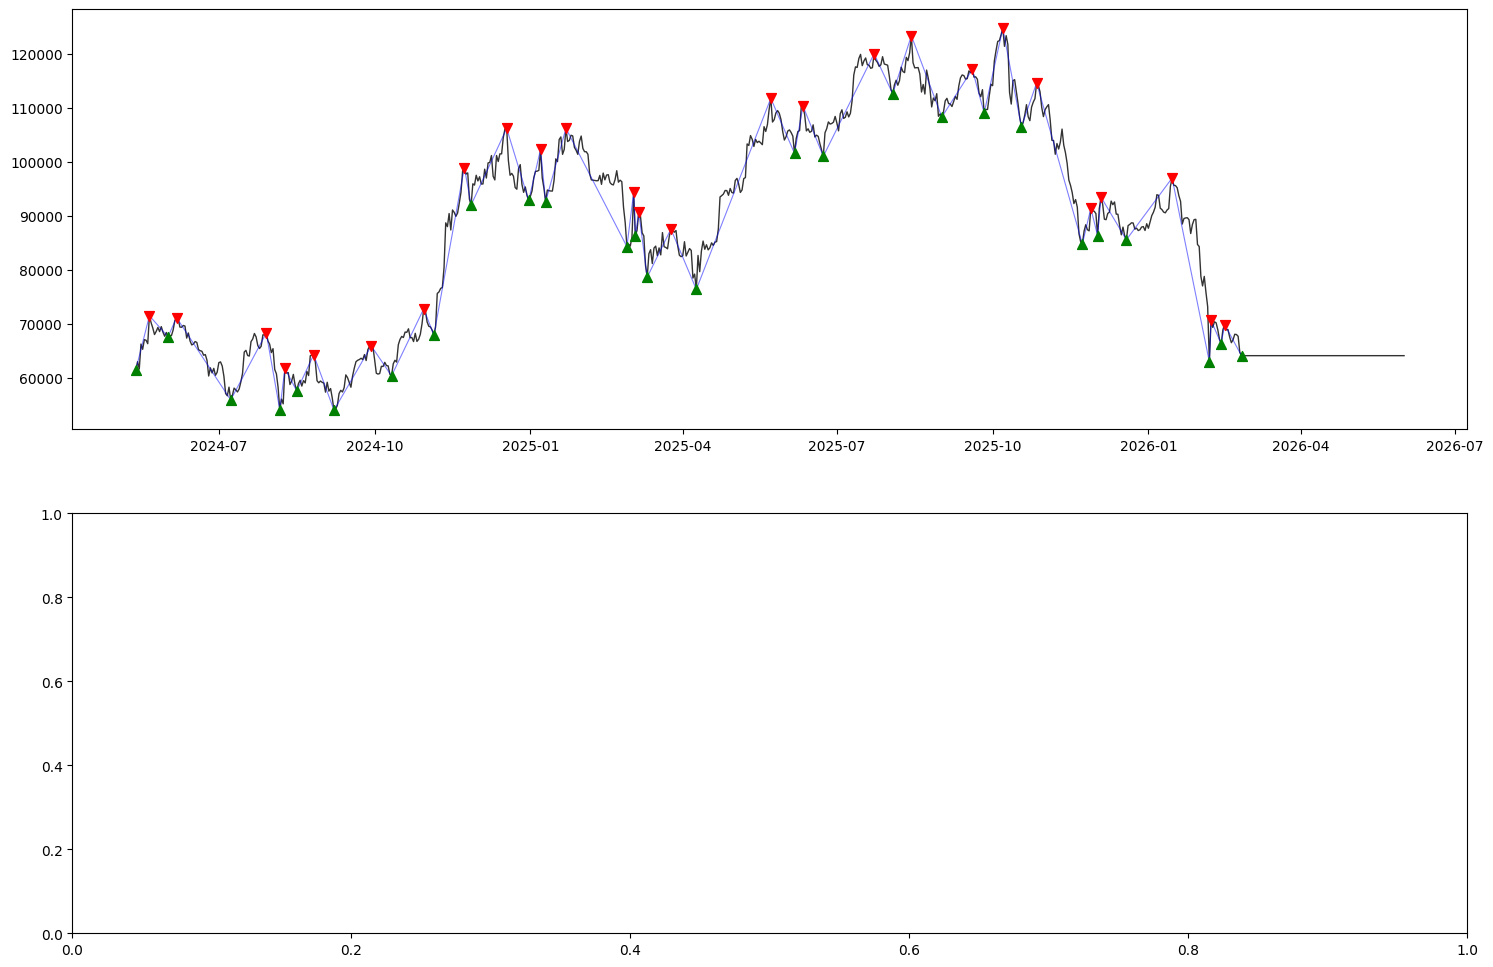

In [10]:
if btc_df is None or df_zz is None:
    print("BTC data not available — skipping zoomed channel visualization.")
else:
    # === Zoom sur la derniere annee pour mieux voir les canaux meso ===
    recent_btc = btc_df[btc_df['time'] >= pd.Timestamp('2024-01-01', tz='UTC')].copy()

    fig, axes = plt.subplots(2, 1, figsize=(18, 12))

    for idx, thresh in enumerate([0.05, 0.10]):
        ax = axes[idx]

        # Use full data for channel building but zoom the view
        result = build_channels(df_zz, thresh, VIOLATION_PCT)
        if result[1] is None:
            continue
        piv_df, chs, (h_df, l_df) = result

        # Price (zoomed)
        ax.plot(recent_btc['time'], recent_btc['close'], color='black', linewidth=1.0, alpha=0.8)

        # Recent pivots only
        recent_piv = piv_df[piv_df['time'] >= pd.Timestamp('2024-01-01', tz='UTC')]
        recent_h = h_df[h_df['time'] >= pd.Timestamp('2024-01-01', tz='UTC')]
        recent_l = l_df[l_df['time'] >= pd.Timestamp('2024-01-01', tz='UTC')]

        if len(recent_piv) > 0:
            ax.plot(recent_piv['time'].values, recent_piv['price'].values,
                   color='blue', linewidth=0.8, alpha=0.5)
        if len(recent_h) > 0:
            ax.scatter(recent_h['time'].values, recent_h['price'].values,
                      color='red', marker='v', s=50, zorder=5)
        if len(recent_l) > 0:
            ax.scatter(recent_l['time'].values, recent_l['price'].values,
                      color='green', marker='^', s=50, zorder=5)

        # Channels (full lines but zoomed view)
        for scale, ls in [('macro', '--'), ('meso', '-')]:
            ch = chs[scale]
            color_r = 'red' if scale == 'macro' else 'darkred'
            color_s = 'green' if scale == 'macro' else 'darkgreen'
            if ch['resistance'][0] is not None:
                plot_channel_line(ax, ch['resistance'][0], ch['resistance'][1],
                                 recent_btc['time'], color_r, ls, f'{scale.title()} Res')
            if ch['support'][0] is not None:
                plot_channel_line(ax, ch['support'][0], ch['support'][1],
                                 recent_btc['time'], color_s, ls, f'{scale.title()} Sup')

        ax.set_title(f'BTC 2024-2026 - ZigZag {thresh*100:.0f}% (Macro + Meso)', fontsize=12)
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.savefig('btc_channels_zoom_2024.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegarde: btc_channels_zoom_2024.png")

## Analyse des resultats

Questions a valider visuellement :
1. Les canaux macro englobent-ils bien le mouvement de prix principal ?
2. Les canaux meso capturent-ils le mouvement recent de facon "tradeable" ?
3. Y a-t-il des zones claires de bounce sur support / rejection sur resistance ?
4. Quel seuil ZigZag produit les canaux les plus coherents ?

### Prochaines etapes
- Tester sur SPY pour comparaison
- Ajuster les parametres visuellement avant de les injecter dans l'algo
- Considerer un 3eme canal (micro) pour le timing d'entree

In [11]:
if btc_df is None or df_zz is None:
    print("BTC data not available — skipping SPY channel comparison.")
else:
    # === Bonus: SPY channels for comparison ===
    spy_history = qb.history(spy, 750, Resolution.DAILY)
    if isinstance(spy_history.index, pd.MultiIndex):
        spy_history = spy_history.loc[spy]

    if len(spy_history) == 0:
        print("SPY data not available from QC Cloud — skipping SPY channel comparison.")
    else:
        spy_df = spy_history.reset_index()

        # Find time column
        for col in spy_df.columns:
            if 'time' in col.lower() or 'date' in col.lower() or col == 'index':
                if col != 'time':
                    spy_df = spy_df.rename(columns={col: 'time'})
                break

        spy_df['time'] = pd.to_datetime(spy_df['time'])
        if spy_df['time'].dt.tz is None:
            spy_df['time'] = spy_df['time'].dt.tz_localize('UTC')

        spy_zz = spy_df[['time', 'close']].copy()

        # SPY channels at 5% and 3%
        fig, axes = plt.subplots(2, 1, figsize=(18, 12))

        for idx, thresh in enumerate([0.03, 0.05]):
            ax = axes[idx]
            ax.plot(spy_df['time'], spy_df['close'], color='black', linewidth=0.8, alpha=0.7)

            result = build_channels(spy_zz, thresh, VIOLATION_PCT)
            if result[1] is None:
                ax.set_title(f'SPY - ZigZag {thresh*100:.0f}% - Pas de canaux')
                continue

            piv_df, chs, (h_df, l_df) = result
            ax.plot(piv_df['time'].values, piv_df['price'].values, color='blue', linewidth=0.6, alpha=0.4)
            ax.scatter(h_df['time'].values, h_df['price'].values, color='red', marker='v', s=20, alpha=0.5)
            ax.scatter(l_df['time'].values, l_df['price'].values, color='green', marker='^', s=20, alpha=0.5)

            for scale, ls in [('macro', '--'), ('meso', '-')]:
                ch = chs[scale]
                color_r = 'red' if scale == 'macro' else 'darkred'
                color_s = 'green' if scale == 'macro' else 'darkgreen'
                if ch['resistance'][0] is not None:
                    plot_channel_line(ax, ch['resistance'][0], ch['resistance'][1],
                                     spy_df['time'], color_r, ls, f'{scale.title()} Res')
                if ch['support'][0] is not None:
                    plot_channel_line(ax, ch['support'][0], ch['support'][1],
                                     spy_df['time'], color_s, ls, f'{scale.title()} Sup')

            ax.set_title(f'SPY - ZigZag {thresh*100:.0f}% ({len(piv_df)} pivots)', fontsize=12)
            ax.legend(loc='upper left', fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.suptitle('SPY - Canaux ZigZag (comparaison)', fontsize=14, y=1.01)
        plt.tight_layout()
        plt.savefig('spy_channels.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Graphique sauvegarde: spy_channels.png")

SPY data not available from QC Cloud — skipping SPY channel comparison.
